In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pickle
from pathlib import Path
from IPython.display import Audio
import IPython.display as ipd
from scipy.io import wavfile
import tempfile
import os
import librosa
import pandas as pd
import seaborn as sns
import h5py
import mne
from scipy.stats import zscore
from mne_bids import BIDSPath, read_raw_bids
from matplotlib_venn import venn2,venn2_circles
from tqdm import tqdm
import xarray as xr
import mne

In [2]:
cm = 1/2.54
plt.rcParams['svg.fonttype'] = 'none'

fontdict = dict(fontsize=7)
fontsize = 7

red = '#A9373B'
blue = '#2369BD'
orange = '#CC8963'
green = '#009944'

stg_color = '#20B2AA'
smc_color = '#6A5ACD'
insula_color = '#D4AF37'

reds = sns.light_palette(red, as_cmap=True)
blues = sns.light_palette(blue, as_cmap=True)
oranges = sns.light_palette(orange, as_cmap=True)
greens = sns.light_palette(green, as_cmap=True)

recon_dir = '/cwork/ns458/ECoG_Recon/'
mne.viz.set_3d_backend('notebook')                    # MNE 3D in-notebook static backend
# text svg

Using notebook 3d backend.


# Aim 1.1

_Load HGA_

In [3]:
import pandas as pd
import numpy as np
from mne_bids import BIDSPath
from tqdm import tqdm

task = [
        'PhonemeSequence', 
        'LexicalNoDelay',
        'LexicalDelay',
        'PictureNaming',
        'SentenceRep',
        ]

ref = 'bipolar'
hga_paths = []
for t in task:
    hga_paths.extend(
        BIDSPath(
            root=f'../results/{t}({ref})',
            datatype='HGA',
            suffix='time',  # 注意这里改成 'time'
            check=False,
        ).match()
    )

# 2. 筛选 perception 和 passive 的数据
HGAs = []
for path in tqdm(hga_paths):
    df = pd.read_csv(path)
    # 只保留 perception 或 passive
    HGAs.append(df)

HGAs = pd.concat(HGAs)

# rename both phase : Resp and Response to Resp
HGAs.loc[HGAs.phase == 'Resp', 'phase'] = 'Response'
HGAs.loc[HGAs.phase == 'Audio', 'phase'] = 'Stimulus'

# phase all convert to lower
HGAs['phase'] = HGAs['phase'].str.lower()

# rename INS to 'Insula'
HGAs.loc[HGAs.roi == 'INS', 'roi'] = 'Insula'
# combine HG to STG
# HGAs.loc[HGAs.roi == 'HG', 'roi'] = 'STG'
# rename CG to Cingulate cortex
HGAs.loc[HGAs.roi == 'PrG', 'roi'] = 'SMC'
HGAs.loc[HGAs.roi == 'PoG', 'roi'] = 'SMC'
HGAs.loc[HGAs.roi == 'Subcentral', 'roi'] = 'SMC'
HGAs.loc[HGAs.roi == 'HG', 'roi'] = 'STG'


HGAs.loc[HGAs.label.isin([
    'ctx_lh_G_and_S_cingul-Mid-Post',
    'ctx_rh_G_and_S_cingul-Mid-Post',
    'ctx_lh_G_cingul-Post-dorsal'
    ]), 'roi'] = 'PCC'


dacc_labels = [
    'ctx_lh_G_and_S_cingul-Mid-Ant',
    'ctx_rh_G_and_S_cingul-Mid-Ant'
]
HGAs.loc[HGAs.label.isin(dacc_labels), 'roi'] = 'dACC' # 这里的 dACC 就是最严格的 SN 枢纽
# rename CG to ACC
HGAs.loc[HGAs.roi=='CG', 'roi'] = 'ACC'

HGAs.head()

100%|██████████| 2254/2254 [00:17<00:00, 132.06it/s]


,time,channel,value,mask,roi,hemi,subject,description,task,phase,modality,label,x,y,z
0,-1.0,D0019_ROG13-14,-0.043502,False,mOccG,R,D0019,Repeat,PhonemeSequence,stimulus,sound,ctx_rh_G_occipital_middle,41.472074,-88.150203,-3.545099
1,-1.0,D0019_RIIH5-6,-0.054793,False,OPC,R,D0019,Repeat,PhonemeSequence,stimulus,sound,ctx_rh_Pole_occipital,11.886836,-94.046488,10.403848
2,-1.0,D0019_ROG4-5,-0.025007,False,sOccG,R,D0019,Repeat,PhonemeSequence,stimulus,sound,ctx_rh_G_occipital_sup,16.298644,-91.860079,29.446276
3,-1.0,D0019_ROG18-19,-0.083139,False,Intersection,R,D0019,Repeat,PhonemeSequence,stimulus,sound,Intersection,41.531682,-78.171196,19.605156
4,-1.0,D0019_RLSO7-8,-0.040828,False,PhG,R,D0019,Repeat,PhonemeSequence,stimulus,sound,ctx_rh_G_oc-temp_med-Parahip,18.457267,-10.274114,-31.949923


In [4]:
# load a exlude pandas df
fpath = '../results/exlude_insula.csv'
exclude_df = pd.read_csv(fpath, index_col=0)
# exclude NaN columns and flatten into single list
exclude_chn = [electrode for item in exclude_df.Exclude.dropna() 
                for electrode in eval(item)]

HGAs = HGAs[~HGAs.channel.isin(exclude_chn)]
print(exclude_chn)

['D0032_LAI4-5', 'D0040_L1IF3-4', 'D0084_RFAI1-2', 'D0086_LTPI2-3', 'D0090_RIA4-5', 'D0096_LFAI2-3', 'D0096_LFAI4-5', 'D0102_RFAI2-3', 'D0106_LTAS2-3', 'D0121_LFMI3-4', 'D0122_LFAI3-4', 'D0125_LIA4-5', 'D0125_LIA7-8']


In [5]:
# Insula region classification function for row-wise application
def classify_insula_row(row, y_threshold=0):
    """
    Classify a single insula electrode into AIC or PIC
    Designed for use with df.apply()
    
    Returns: 'AIC', 'PIC', or original roi if not insula
    """
    if row['roi'] != 'Insula':
        return row['roi']
    
    label = row['label']
    y_coord = row['y']
    
    # AIC classification conditions
    if ('G_insular_short' in label or 
        'S_circular_insula_ant' in label or
        ('S_circular_insula_sup' in label and y_coord > y_threshold) or
        ('S_circular_insula_inf' in label and y_coord > y_threshold)):
        return 'AIC'
    
    # PIC classification conditions  
    elif ('G_Ins_lg_and_S_cent_ins' in label or
          ('S_circular_insula_sup' in label and y_coord <= y_threshold) or
          ('S_circular_insula_inf' in label and y_coord <= y_threshold)):
        return 'PIC'
    
    # If no conditions match, return original
    return row['roi']

# Apply classification to entire DataFrame (function handles filtering internally)
HGAs['roi'] = HGAs.apply(classify_insula_row, axis=1, y_threshold=0)

# Statistics results
print(f"AIC electrode count: {len(HGAs[HGAs['roi'] == 'AIC'])}")
print(f"PIC electrode count: {len(HGAs[HGAs['roi'] == 'PIC'])}")

# Check unclassified electrodes
unclassified = HGAs[HGAs['roi'] == 'Insula']
if len(unclassified) > 0:
    print(f"Unclassified electrode count: {len(unclassified)}")
    print("Unclassified label types:", unclassified['label'].unique())
    
HGAs.head()

AIC electrode count: 472320
PIC electrode count: 417344


,time,channel,value,mask,roi,hemi,subject,description,task,phase,modality,label,x,y,z
0,-1.0,D0019_ROG13-14,-0.043502,False,mOccG,R,D0019,Repeat,PhonemeSequence,stimulus,sound,ctx_rh_G_occipital_middle,41.472074,-88.150203,-3.545099
1,-1.0,D0019_RIIH5-6,-0.054793,False,OPC,R,D0019,Repeat,PhonemeSequence,stimulus,sound,ctx_rh_Pole_occipital,11.886836,-94.046488,10.403848
2,-1.0,D0019_ROG4-5,-0.025007,False,sOccG,R,D0019,Repeat,PhonemeSequence,stimulus,sound,ctx_rh_G_occipital_sup,16.298644,-91.860079,29.446276
3,-1.0,D0019_ROG18-19,-0.083139,False,Intersection,R,D0019,Repeat,PhonemeSequence,stimulus,sound,Intersection,41.531682,-78.171196,19.605156
4,-1.0,D0019_RLSO7-8,-0.040828,False,PhG,R,D0019,Repeat,PhonemeSequence,stimulus,sound,ctx_rh_G_oc-temp_med-Parahip,18.457267,-10.274114,-31.949923


In [6]:
fsavg_lh_surf, _ = mne.read_surface(f"{recon_dir}/fsaverage/surf/lh.pial")
cvs_lh_surf, _ = mne.read_surface(f"{recon_dir}/cvs_avg35_inMNI152/surf/lh.pial")
translation = cvs_lh_surf.mean(axis=0) - fsavg_lh_surf.mean(axis=0)
HGAs[['x','y','z']] = HGAs[['x','y','z']].values + translation

## Part I

In [7]:
picks = HGAs[HGAs.task=='LexicalDelay'].subject.unique()
picks = picks[-len(picks)//2:]

NameError: name 'hemi' is not defined

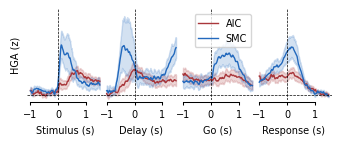

In [8]:
rois = ['AIC', 'SMC']

colors = [red, blue]

subset = HGAs[
    (HGAs.description == 'Repeat')
    & (HGAs.modality=='sound')
    & (HGAs.hemi=='L')
    & (HGAs.task=='LexicalDelay')
    & (HGAs.subject.isin(picks))
    & (HGAs.subject!='D0007')
    & (HGAs.roi.isin(rois))
]

phases = ['stimulus', 'delay', 'go' ,'response']

fig, axes = plt.subplots(nrows=1, ncols=len(phases), figsize=(2.5*len(phases)*cm, 3*cm),)

plt.subplots_adjust(wspace=0)

# Create plots with proper labels for legend
for (ax, phase) in zip(axes, phases):
    
    legend = True if ax == axes[-2] else False
    line1 = sns.lineplot(
        data=subset[(subset.phase == phase)],
        x='time',
        y='value',
        hue='roi',
        hue_order=rois,
        ax=ax,
        palette=colors,
        legend=legend,
        lw=1
    )
    
    ax.set_xlabel(f'{phase.capitalize()} (s)', fontsize=7)

for ax in fig.axes:
    ax.axvline(x=0, color='k', linestyle='--', linewidth=0.5)
    ax.axhline(y=0, color='k', linestyle='--', linewidth=0.5)
    
    ax.tick_params(labelsize=7, width=.75, length=2, which='both')
    plt.setp(ax.spines.values(), linewidth=.75)
    
    sns.despine(ax=ax, offset=1, trim=True)
    
    # Only add legend to the last axis if it has artists with labels
    if ax == axes[-2] and ax.get_legend() is not None:
        ax.legend(title='', fontsize=7)
    else:
        # Remove legend from other axes
        legend = ax.get_legend()
        if legend is not None:
            legend.remove()
    
    ax.set_yticklabels([])
    ax.set_yticks([])
    # remove y spine
    ax.spines['left'].set_visible(False)
    
    ax.set_ylim(-0.1, 1.5)
    
    if ax != axes[0]:
        # ax.set_xlabel('Time (s)', fontsize=7)
        ax.set_ylabel('', fontsize=7)
    else:
        ax.set_ylabel('HGA (z)', fontsize=7)

plt.savefig(f'grantfig/aim1_{rois[0]}_{hemi}_HGAs.svg',dpi=300,bbox_inches='tight')
plt.show()

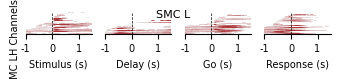

In [ ]:
import xarray as xr

roi = 'SMC'
hemi = 'L'
cmap=reds
phases = ['stimulus', 'delay', 'go', 'response']

subset = HGAs[
    (HGAs.description == 'Repeat')
    & (HGAs.modality == 'sound')
    & (HGAs.hemi == hemi)
    & (HGAs.roi == roi)
    & (HGAs.subject.isin(picks))
]

agg_data = subset.groupby(['channel', 'time', 'phase']).agg({
    'value': 'mean',
    'mask': lambda x: x.any()
}).reset_index()

agg_data.loc[~agg_data['mask'], 'value'] = np.nan

max_channels = 0
phase_channel_map = {}
for phase in phases:
    phase_data = agg_data[agg_data.phase == phase]
    sig_channels = phase_data[phase_data['mask'] == True]['channel'].unique()
    first_sig_times = []
    for ch in sig_channels:
        ch_data = phase_data[phase_data.channel == ch]
        sig_times = ch_data[ch_data['mask'] == True]['time'].values
        if len(sig_times) > 0:
            first_sig_times.append((ch, sig_times.min()))
        else:
            first_sig_times.append((ch, np.inf))
    sorted_channels = [ch for ch, _ in sorted(first_sig_times, key=lambda x: x[1])]
    phase_channel_map[phase] = sorted_channels
    max_channels = max(max_channels, len(sorted_channels))

fig, axes = plt.subplots(nrows=1, ncols=len(phases), figsize=(2.5*len(phases)*cm, float(0.02*max_channels*cm)))

for ax, phase in zip(axes, phases):
    sorted_channels = phase_channel_map[phase]
    phase_data = agg_data[agg_data.phase == phase]
    
    if len(sorted_channels) == 0:
        ax.text(0.5, 0.5, 'No significant\nchannels', 
                ha='center', va='center', transform=ax.transAxes, fontsize=7)
        ax.set_xlabel(f'{phase.capitalize()} (s)', fontsize=7)
        ax.set_xticks([])
        ax.set_yticks([])
        ax.set_ylim(0, max_channels)
        continue
    
    phase_data_filtered = phase_data[phase_data.channel.isin(sorted_channels)]
    pivot_data = phase_data_filtered.pivot(index='channel', columns='time', values='value')
    pivot_data = pivot_data.reindex(index=sorted_channels)
    
    da = xr.DataArray(
        pivot_data.values,
        coords={'channel': pivot_data.index, 'time': pivot_data.columns},
        dims=['channel', 'time']
    )
    
    time_values = da.coords['time'].values.astype(float)
    if len(time_values) > 1:
        step = np.diff(time_values).mean()
    else:
        step = 0.01  # fallback for single time point
    time_edges = np.concatenate(([time_values[0] - step/2], time_values[:-1] + step/2, [time_values[-1] + step/2]))
    channel_edges = np.arange(len(sorted_channels) + 1)
    
    # Build meshgrid for pcolormesh
    T, C = np.meshgrid(time_edges, channel_edges)
    
    im = ax.pcolormesh(T, C, da.values, cmap=cmap, vmin=0, vmax=1.5, shading='auto', rasterized=True)
    
    sns.despine(ax=ax, offset=0, trim=False)
    ax.spines['left'].set_visible(False)
    # fixed ticks at -1, 0, 1
    ax.set_xticks([-1, 0, 1])
    ax.set_xticklabels(['-1','0', '1'], fontsize=7)
    
    ax.set_yticks([])
    ax.set_xlabel(f'{phase.capitalize()} (s)', fontsize=7)
    
    ax.axvline(x=0, color='k', linestyle='--', linewidth=0.5)
    ax.set_ylim(0, max_channels)
    
    if ax == axes[0]:
        ax.set_ylabel(f'{roi} {hemi}H Channels (n={len(sorted_channels)})', fontsize=7)
    else:
        ax.set_ylabel(f'', fontsize=7)

plt.suptitle(f'{roi} {hemi}', fontsize=8)
plt.savefig(f'grantfig/aims1_heatmap_{roi}_{hemi}_channels.svg',dpi=300,bbox_inches='tight')
plt.show()

In [ ]:
phase = 'delay'

spatial = subset[
    (subset.phase == phase)
    & (subset.time>0)
    & (subset.time<1)
    ].groupby('channel').agg({
    'value': 'mean',  
    'x': 'first',
    'y': 'first', 
    'z': 'first',
    'roi': 'first',
    'label': 'first',
    'phase': 'first',
    'hemi': 'first',
    'subject': 'first',
    'description': 'first',
    'task': 'first'
}).reset_index()

spatial.rename(columns={'value': 'HGA'}, inplace=True)
spatial.head()

,channel,HGA,x,y,z,roi,label,phase,hemi,subject,description,task
0,D0079_LAI2-3,0.077265,-30.267197,23.287619,-33.248411,AIC,ctx_lh_G_insular_short,delay,L,D0079,Repeat,LexicalDelay
1,D0079_LAI7-8,0.215726,-30.678545,27.300663,-15.662618,AIC,ctx_lh_S_circular_insula_sup,delay,L,D0079,Repeat,LexicalDelay
2,D0079_LFAI1-2,0.181452,-28.670343,45.423928,-16.906951,AIC,ctx_lh_S_circular_insula_sup,delay,L,D0079,Repeat,LexicalDelay
3,D0079_LFAI2-3,0.264583,-32.107581,45.323225,-17.455744,AIC,ctx_lh_S_circular_insula_sup,delay,L,D0079,Repeat,LexicalDelay
4,D0079_LPAM14-15,0.229109,-48.538739,-4.513831,17.263383,SMC,ctx_lh_S_postcentral,delay,L,D0079,Repeat,LexicalDelay


Reading labels from parcellation...
   read 75 labels from /cwork/ns458/ECoG_Recon/cvs_avg35_inMNI152/label/lh.aparc.a2009s.annot
   read 75 labels from /cwork/ns458/ECoG_Recon/cvs_avg35_inMNI152/label/rh.aparc.a2009s.annot


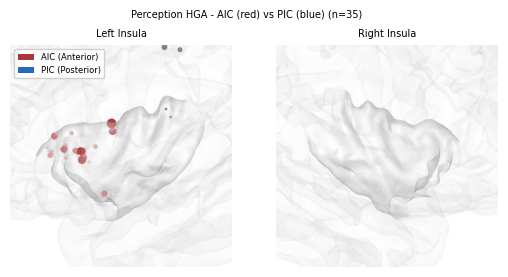

In [ ]:
import numpy as np
import pyvista as pv
import matplotlib.pyplot as plt
from mne.viz import Brain
from scipy.spatial import cKDTree
import matplotlib.colors as mcolors

# 读取aparc.a2009s labels
labels = mne.read_labels_from_annot(
    subject='cvs_avg35_inMNI152', parc='aparc.a2009s',  
    surf_name='pial',
    hemi='both', subjects_dir=recon_dir
)

# Insula相关的labels (aparc.a2009s)
insula_patterns = ['G_insular_short', 'G_Ins_lg_and_S_cent_ins', 
                   'S_circular_insula_ant', 'S_circular_insula_inf', 'S_circular_insula_sup']

# 加载pial表面用于投影
lh_pial_coords, _ = mne.read_surface(f"{recon_dir}/cvs_avg35_inMNI152/surf/lh.pial")
rh_pial_coords, _ = mne.read_surface(f"{recon_dir}/cvs_avg35_inMNI152/surf/rh.pial")
lh_tree = cKDTree(lh_pial_coords)
rh_tree = cKDTree(rh_pial_coords)

# 计算insula区域的中心点
def get_insula_center(labels, hemi, pial_coords):
    vertices = []
    for lab in labels:
        if lab.hemi == hemi and any(p in lab.name for p in insula_patterns):
            vertices.extend(lab.vertices)
    if vertices:
        insula_coords = pial_coords[vertices]
        return insula_coords.mean(axis=0)
    return None

lh_insula_center = get_insula_center(labels, 'lh', lh_pial_coords)
rh_insula_center = get_insula_center(labels, 'rh', rh_pial_coords)

# 创建左右半球Brain对象
lh_brain = Brain(
    "cvs_avg35_inMNI152", subjects_dir=recon_dir, surf="pial",
    hemi="lh", background="white", show=False,
    cortex=(0.9, 0.9, 0.9), alpha=0.05, size=(800, 800)
)
rh_brain = Brain(
    "cvs_avg35_inMNI152", subjects_dir=recon_dir, surf="pial",
    hemi="rh", background="white", show=False,
    cortex=(0.9, 0.9, 0.9), alpha=0.05, size=(800, 800)
)


for lab in labels:
    if any(pattern in lab.name for pattern in insula_patterns):
        if lab.hemi == 'lh':
            lh_brain.add_label(lab, borders=False, color=(0.9, 0.9, 0.9), alpha=0.6)
        elif lab.hemi == 'rh':
            rh_brain.add_label(lab, borders=False, color=(0.9, 0.9, 0.9), alpha=0.6)

# HGA数据 - 使用与 Cell 13 完全相同的数据
cord = spatial[['x', 'y', 'z']].values
hga_values = spatial['HGA'].values
roi_values = spatial['roi'].values

mask_lh = cord[:, 0] < 0
mask_rh = cord[:, 0] > 0

# 设置 colormap 和归一化 - 与 Cell 13 完全相同
vmin, vmax = 0, np.percentile(hga_values, 95)
norm = mcolors.Normalize(vmin=vmin, vmax=vmax)

# 点大小映射参数 - 与 Cell 13 完全相同
size_min, size_max = 8, 35

def hga_to_size(hga, vmin, vmax, size_min, size_max):
    normalized = np.clip((hga - vmin) / (vmax - vmin), 0, 1)
    return size_min + normalized * (size_max - size_min)

def add_electrodes_with_hga_colored(brain, coords, hga_vals, roi_vals, tree, pial_coords, size_min, size_max):
    _, indices = tree.query(coords)
    coords_proj = pial_coords[indices]
    
    for i in range(len(coords_proj)):
        pt = coords_proj[i:i+1]
        hga = hga_vals[i]
        roi = roi_vals[i]
        
        # 根据ROI设置颜色，其他参数与 Cell 13 完全相同
        if roi == 'AIC':
            cmap = reds
            color = cmap(norm(hga))  # Anterior insula = red
        elif roi == 'PIC':
            cmap = blues
            color = cmap(norm(hga))  # Posterior insula = blue
        else:
            color = 'gray'  # 其他ROI用灰色
        
        size = hga_to_size(hga, vmin, vmax, size_min, size_max)
        
        cloud = pv.PolyData(pt)
        brain._renderer.plotter.add_mesh(
            cloud,
            render_points_as_spheres=True,
            point_size=size,
            color=color,
            lighting=False,  # 与 Cell 13 完全相同，无 opacity 参数
        )

# 添加左半球电极
if mask_lh.any():
    lh_cord = cord[mask_lh]
    lh_hga = hga_values[mask_lh]
    lh_roi = roi_values[mask_lh]
    add_electrodes_with_hga_colored(lh_brain, lh_cord, lh_hga, lh_roi, lh_tree, lh_pial_coords, 
                                    size_min, size_max)

# 添加右半球电极
if mask_rh.any():
    rh_cord = cord[mask_rh]
    rh_hga = hga_values[mask_rh]
    rh_roi = roi_values[mask_rh]
    add_electrodes_with_hga_colored(rh_brain, rh_cord, rh_hga, rh_roi, rh_tree, rh_pial_coords, 
                                    size_min, size_max)

# 设置视角 - 聚焦在insula中心
lh_brain.show_view(azimuth=180, elevation=90, distance=180, focalpoint=lh_insula_center)
rh_brain.show_view(azimuth=0, elevation=90, distance=180, focalpoint=rh_insula_center)

# 截图并显示
fig, axes = plt.subplots(1, 2, figsize=(16*cm, 8*cm))

axes[0].imshow(lh_brain.screenshot(mode="rgb"))
axes[0].axis("off")
axes[0].set_title("Left Insula", fontsize=fontsize)

axes[1].imshow(rh_brain.screenshot(mode="rgb"))
axes[1].axis("off")
axes[1].set_title("Right Insula", fontsize=fontsize)

# 
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor=red, label='AIC (Anterior)'),
    Patch(facecolor=blue, label='PIC (Posterior)')
]
axes[0].legend(handles=legend_elements, loc='upper left', fontsize=fontsize-1, framealpha=0.9)

plt.suptitle("Perception HGA - AIC (red) vs PIC (blue) (n={})".format(len(spatial)), fontsize=fontsize)

lh_brain.close()
rh_brain.close()

plt.subplots_adjust(bottom=0.15)

# plt.savefig(f'../img/fig2/fig2_AIPI_spatial_{phase}.svg', dpi=300, bbox_inches='tight')

## Part II

In [ ]:
import pandas as pd
import numpy as np
from mne_bids import BIDSPath
from tqdm import tqdm

task = [
        'LexicalNoDelay',
        'LexicalDelay',
        'PictureNaming',
        ]

ref = 'bipolar'
hga_paths = []
for t in task:
    hga_paths.extend(
        BIDSPath(
            root=f'../results/{t}({ref})',
            datatype='HGA',
            suffix='zscore',  
            check=False,
        ).match()
    )

# 2. 筛选 perception 和 passive 的数据
ZAs = []
for path in tqdm(hga_paths):
    df = pd.read_csv(path)
    # 只保留 perception 或 passive
    ZAs.append(df)

ZAs = pd.concat(ZAs)

# rename both phase : Resp and Response to Resp
ZAs.loc[ZAs.phase == 'Resp', 'phase'] = 'Response'
ZAs.loc[ZAs.phase == 'Audio', 'phase'] = 'Stimulus'

# phase all convert to lower
ZAs['phase'] = ZAs['phase'].str.lower()

# rename INS to 'Insula'
ZAs.loc[ZAs.roi == 'INS', 'roi'] = 'Insula'
# combine HG to STG
# HGAs.loc[HGAs.roi == 'HG', 'roi'] = 'STG'
ZAs.loc[ZAs.roi == 'PrG', 'roi'] = 'SMC'
ZAs.loc[ZAs.roi == 'PoG', 'roi'] = 'SMC'
ZAs.loc[ZAs.roi == 'Subcentral', 'roi'] = 'SMC'


ZAs.loc[ZAs.label.isin([
    'ctx_lh_G_and_S_cingul-Mid-Post',
    'ctx_rh_G_and_S_cingul-Mid-Post',
    'ctx_lh_G_cingul-Post-dorsal'
    ]), 'roi'] = 'PCC'


dacc_labels = [
    'ctx_lh_G_and_S_cingul-Mid-Ant',
    'ctx_rh_G_and_S_cingul-Mid-Ant'
]
ZAs.loc[ZAs.label.isin(dacc_labels), 'roi'] = 'dACC' # 这里的 dACC 就是最严格的 SN 枢纽
# rename CG to ACC
ZAs.loc[ZAs.roi=='CG', 'roi'] = 'ACC'
ZAs.head()

100%|██████████| 1214/1214 [00:41<00:00, 29.43it/s]


,time,channel,value,mask,subject,description,task,phase,modality,label,roi,hemi,x,y,z
0,-1.0,D0024_LOF1-2,-0.229030,False,D0024,Decision,LexicalNoDelay,stimulus,sound,ctx_lh_G_orbital,OFC,L,-8.479743,30.393553,-27.559950
1,-1.0,D0024_LOF3-4,0.052873,False,D0024,Decision,LexicalNoDelay,stimulus,sound,ctx_lh_G_orbital,OFC,L,-29.806176,31.473703,-22.186615
2,-1.0,D0024_LTG3-4,0.069723,False,D0024,Decision,LexicalNoDelay,stimulus,sound,ctx_lh_G_and_S_subcentral,SMC,L,-61.673107,6.449220,2.700920
3,-1.0,D0024_LTG4-5,0.011154,False,D0024,Decision,LexicalNoDelay,stimulus,sound,ctx_lh_G_and_S_subcentral,SMC,L,-64.363938,-4.606566,7.515506
4,-1.0,D0024_LTG5-6,0.026363,False,D0024,Decision,LexicalNoDelay,stimulus,sound,ctx_lh_G_and_S_subcentral,SMC,L,-65.187402,-14.882005,13.114168


In [ ]:
# Insula region classification function for row-wise application
def classify_insula_row(row, y_threshold=0):
    """
    Classify a single insula electrode into AIC or PIC
    Designed for use with df.apply()
    
    Returns: 'AIC', 'PIC', or original roi if not insula
    """
    if row['roi'] != 'Insula':
        return row['roi']
    
    label = row['label']
    y_coord = row['y']
    
    # AIC classification conditions
    if ('G_insular_short' in label or 
        'S_circular_insula_ant' in label or
        ('S_circular_insula_sup' in label and y_coord > y_threshold) or
        ('S_circular_insula_inf' in label and y_coord > y_threshold)):
        return 'AIC'
    
    # PIC classification conditions  
    elif ('G_Ins_lg_and_S_cent_ins' in label or
          ('S_circular_insula_sup' in label and y_coord <= y_threshold) or
          ('S_circular_insula_inf' in label and y_coord <= y_threshold)):
        return 'PIC'
    
    # If no conditions match, return original
    return row['roi']

# Apply classification to entire DataFrame (function handles filtering internally)
ZAs['roi'] = ZAs.apply(classify_insula_row, axis=1, y_threshold=0)

# Statistics results
print(f"AIC electrode count: {len(ZAs[ZAs['roi'] == 'AIC'])}")
print(f"PIC electrode count: {len(ZAs[ZAs['roi'] == 'PIC'])}")

# Check unclassified electrodes
unclassified = ZAs[ZAs['roi'] == 'Insula']
if len(unclassified) > 0:
    print(f"Unclassified electrode count: {len(unclassified)}")
    print("Unclassified label types:", unclassified['label'].unique())
    
ZAs.head()

AIC electrode count: 1052800
PIC electrode count: 876160


,time,channel,value,mask,subject,description,task,phase,modality,label,roi,hemi,x,y,z
0,-1.0,D0024_LOF1-2,-0.229030,False,D0024,Decision,LexicalNoDelay,stimulus,sound,ctx_lh_G_orbital,OFC,L,-8.479743,30.393553,-27.559950
1,-1.0,D0024_LOF3-4,0.052873,False,D0024,Decision,LexicalNoDelay,stimulus,sound,ctx_lh_G_orbital,OFC,L,-29.806176,31.473703,-22.186615
2,-1.0,D0024_LTG3-4,0.069723,False,D0024,Decision,LexicalNoDelay,stimulus,sound,ctx_lh_G_and_S_subcentral,SMC,L,-61.673107,6.449220,2.700920
3,-1.0,D0024_LTG4-5,0.011154,False,D0024,Decision,LexicalNoDelay,stimulus,sound,ctx_lh_G_and_S_subcentral,SMC,L,-64.363938,-4.606566,7.515506
4,-1.0,D0024_LTG5-6,0.026363,False,D0024,Decision,LexicalNoDelay,stimulus,sound,ctx_lh_G_and_S_subcentral,SMC,L,-65.187402,-14.882005,13.114168


In [ ]:
fsavg_lh_surf, _ = mne.read_surface(f"{recon_dir}/fsaverage/surf/lh.pial")
cvs_lh_surf, _ = mne.read_surface(f"{recon_dir}/cvs_avg35_inMNI152/surf/lh.pial")
translation = cvs_lh_surf.mean(axis=0) - fsavg_lh_surf.mean(axis=0)
ZAs[['x','y','z']] = ZAs[['x','y','z']].values + translation

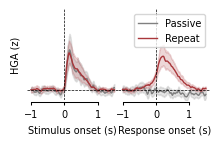

In [ ]:
rois = ['PIC']

# tasks = ['LexicalDelay', 'LexicalNoDelay']
tasks = ['LexicalDelay', 'LexicalNoDelay', 'PictureNaming']

descs = ['Passive', 'Repeat']

colors = ['gray', red]
modality = 'sound'

subset = HGAs[
    (HGAs.task.isin(tasks))
    & (HGAs.roi.isin(rois))
    # & (HGAs.hemi == 'L')
    # & (~HGAs.subject.isin(['D0121','D0064','D0123','D0125','D0118']))
    # & (HGAs.description.isin(['Passive']))
    & (HGAs.modality==modality)
]

subset_z = ZAs[
    (ZAs.task.isin(tasks))
    & (ZAs.channel.isin(subset.channel.unique()))
    # & (ZAs.hemi == 'L')
    & (ZAs.time<1.5)
    & (ZAs.description.isin(descs))
    # & (~ZAs.subject.isin(['D0121','D0064','D0123','D0125','D0129','D0118']))
    & (ZAs.modality==modality)
]

phases = ['stimulus', 'response']
fig, axes = plt.subplots(nrows=1, ncols=len(phases), figsize=(3*(len(phases))*cm, 3*cm))

plt.subplots_adjust(wspace=0)

# Create plots with proper labels for legend
for (phase, ax) in zip(phases, axes):
        
    legend_ = True if ax==axes[1] else False
    sns.lineplot(
        data=subset_z[(subset_z.phase == phase)],
        x='time',
        y='value',
        hue='description',
        hue_order=descs,
        ax=ax,
        palette=colors,
        legend=legend_,
        lw=1
    )
    ax.set_xlabel(f'{phase.capitalize()} onset (s)', fontsize=7)   
    

for ax in fig.axes:
    ax.axvline(x=0, color='k', linestyle='--', linewidth=0.5)
    ax.axhline(y=0, color='k', linestyle='--', linewidth=0.5)
    
    ax.tick_params(labelsize=7, width=.75, length=2, which='both')
    plt.setp(ax.spines.values(), linewidth=.75)
    sns.despine(ax=ax, offset=1, trim=True)
    
    # Only add legend to the last axis if it has artists with labels
    if ax.get_legend() is not None:
        ax.legend(title='', fontsize=7)
    else:
        # Remove legend from other axes
        legend = ax.get_legend()
        if legend is not None:
            legend.remove()
    
    ax.set_yticklabels([])
    ax.set_yticks([])
    # remove y spine
    ax.spines['left'].set_visible(False)
    
    ax.set_ylim(-0.1, 0.8)
    
axes[0].set_ylabel('HGA (z)', fontsize=7)
for ax in axes[1:]:
    ax.set_ylabel('', fontsize=7)
    
# plt.suptitle(f'PictureNaming-AIC-{modality}', fontsize=9)
plt.savefig(f'grantfig/aim1_compare_action_{rois[0]}_lexical_{modality}.svg', dpi=300, bbox_inches='tight')
plt.show()

# Aim 1.2

## Part I

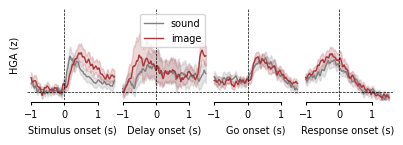

In [10]:
rois = ['AIC']

# tasks = ['LexicalDelay', 'LexicalNoDelay']

tasks = ['PictureNaming']
descs = ['Passive', 'Repeat']

colors = ['gray', red]
modality = ['sound','image']

subset = HGAs[
    (HGAs.task.isin(tasks))
    & (HGAs.roi.isin(rois))
    # & (HGAs.hemi == 'L')
    # & (HGAs.description.isin(['Decision']))
    & (HGAs.modality.isin(modality))
    & (HGAs.subject!='D0121')
]

phases = ['stimulus', 'delay', 'go' ,'response']
fig, axes = plt.subplots(nrows=1, ncols=len(phases), figsize=(3*(len(phases))*cm, 3*cm))

plt.subplots_adjust(wspace=0)

# Create plots with proper labels for legend
for (phase, ax) in zip(phases, axes):
        
    legend_ = True if ax==axes[1] else False
    sns.lineplot(
        data=subset[(subset.phase == phase)],
        x='time',
        y='value',
        hue='modality',
        hue_order=modality,
        ax=ax,
        palette=colors,
        legend=legend_,
        lw=1
    )
    ax.set_xlabel(f'{phase.capitalize()} onset (s)', fontsize=7)   
    

for ax in fig.axes:
    ax.axvline(x=0, color='k', linestyle='--', linewidth=0.5)
    ax.axhline(y=0, color='k', linestyle='--', linewidth=0.5)
    
    ax.tick_params(labelsize=7, width=.75, length=2, which='both')
    plt.setp(ax.spines.values(), linewidth=.75)
    sns.despine(ax=ax, offset=1, trim=True)
    
    # Only add legend to the last axis if it has artists with labels
    if ax.get_legend() is not None:
        ax.legend(title='', fontsize=7)
    else:
        # Remove legend from other axes
        legend = ax.get_legend()
        if legend is not None:
            legend.remove()
    
    ax.set_yticklabels([])
    ax.set_yticks([])
    # remove y spine
    ax.spines['left'].set_visible(False)
    
    ax.set_ylim(-0.1, 1)
    
axes[0].set_ylabel('HGA (z)', fontsize=7)
for ax in axes[1:]:
    ax.set_ylabel('', fontsize=7)
    
# plt.suptitle(f'PictureNaming-AIC-{modality}', fontsize=9)
plt.savefig(f'grantfig/aim1_picturenaming_{rois[0]}_modality.svg', dpi=300, bbox_inches='tight')
plt.show()

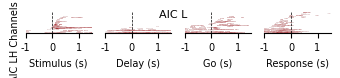

In [12]:
import xarray as xr

roi = 'AIC'
hemi = 'L'
cmap=reds
modality='sound'
phases = ['stimulus', 'delay', 'go', 'response']

subset = HGAs[
    (HGAs.description == 'Repeat')
    & (HGAs.modality == modality)
    & (HGAs.hemi == hemi)
    & (HGAs.task.isin(tasks))
    & (HGAs.roi == roi)
]

agg_data = subset.groupby(['channel', 'time', 'phase']).agg({
    'value': 'mean',
    'mask': lambda x: x.any()
}).reset_index()

agg_data.loc[~agg_data['mask'], 'value'] = np.nan

max_channels = 0
phase_channel_map = {}
for phase in phases:
    phase_data = agg_data[agg_data.phase == phase]
    sig_channels = phase_data[phase_data['mask'] == True]['channel'].unique()
    first_sig_times = []
    for ch in sig_channels:
        ch_data = phase_data[phase_data.channel == ch]
        sig_times = ch_data[ch_data['mask'] == True]['time'].values
        if len(sig_times) > 0:
            first_sig_times.append((ch, sig_times.min()))
        else:
            first_sig_times.append((ch, np.inf))
    sorted_channels = [ch for ch, _ in sorted(first_sig_times, key=lambda x: x[1])]
    phase_channel_map[phase] = sorted_channels
    max_channels = max(max_channels, len(sorted_channels))

fig, axes = plt.subplots(nrows=1, ncols=len(phases), figsize=(2.5*len(phases)*cm, float(0.02*max_channels*cm)))

for ax, phase in zip(axes, phases):
    sorted_channels = phase_channel_map[phase]
    phase_data = agg_data[agg_data.phase == phase]
    
    if len(sorted_channels) == 0:
        ax.text(0.5, 0.5, 'No significant\nchannels', 
                ha='center', va='center', transform=ax.transAxes, fontsize=7)
        ax.set_xlabel(f'{phase.capitalize()} (s)', fontsize=7)
        ax.set_xticks([])
        ax.set_yticks([])
        ax.set_ylim(0, max_channels)
        continue
    
    phase_data_filtered = phase_data[phase_data.channel.isin(sorted_channels)]
    pivot_data = phase_data_filtered.pivot(index='channel', columns='time', values='value')
    pivot_data = pivot_data.reindex(index=sorted_channels)
    
    da = xr.DataArray(
        pivot_data.values,
        coords={'channel': pivot_data.index, 'time': pivot_data.columns},
        dims=['channel', 'time']
    )
    
    time_values = da.coords['time'].values.astype(float)
    if len(time_values) > 1:
        step = np.diff(time_values).mean()
    else:
        step = 0.01  # fallback for single time point
    time_edges = np.concatenate(([time_values[0] - step/2], time_values[:-1] + step/2, [time_values[-1] + step/2]))
    channel_edges = np.arange(len(sorted_channels) + 1)
    
    # Build meshgrid for pcolormesh
    T, C = np.meshgrid(time_edges, channel_edges)
    
    im = ax.pcolormesh(T, C, da.values, cmap=cmap, vmin=0, vmax=1.5, shading='auto', rasterized=True)
    
    sns.despine(ax=ax, offset=0, trim=False)
    ax.spines['left'].set_visible(False)
    # fixed ticks at -1, 0, 1
    ax.set_xticks([-1, 0, 1])
    ax.set_xticklabels(['-1','0', '1'], fontsize=7)
    
    ax.set_yticks([])
    ax.set_xlabel(f'{phase.capitalize()} (s)', fontsize=7)
    
    ax.axvline(x=0, color='k', linestyle='--', linewidth=0.5)
    ax.set_ylim(0, max_channels)
    
    if ax == axes[0]:
        ax.set_ylabel(f'{roi} {hemi}H Channels (n={len(sorted_channels)})', fontsize=7)
    else:
        ax.set_ylabel(f'', fontsize=7)

plt.suptitle(f'{roi} {hemi}', fontsize=8)
plt.savefig(f'grantfig/aims1_picturenaming_heatmap_{roi}_{hemi}_channels_{modality}.svg',dpi=300,bbox_inches='tight')
plt.show()

## Part II

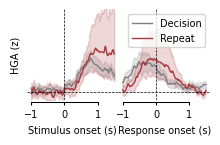

In [ ]:
rois = ['AIC']

tasks = ['LexicalNoDelay']

descs = ['Passive', 'Repeat']

colors = ['gray', red]
modality = ['sound']
description = ['Decision','Repeat']
subset = HGAs[
    (HGAs.task.isin(tasks))
    & (HGAs.roi.isin(rois))
    # & (HGAs.hemi == 'L')
    & (HGAs.description.isin(description))
    & (HGAs.modality.isin(modality))
    & (HGAs.subject!='D0121')
]


phases = ['stimulus' ,'response']
fig, axes = plt.subplots(nrows=1, ncols=len(phases), figsize=(3*(len(phases))*cm, 3*cm))

plt.subplots_adjust(wspace=0)

# Create plots with proper labels for legend
for (phase, ax) in zip(phases, axes):
        
    legend_ = True if ax==axes[1] else False
    sns.lineplot(
        data=subset[(subset.phase == phase)],
        x='time',
        y='value',
        hue='description',
        hue_order=description,
        ax=ax,
        palette=colors,
        legend=legend_,
        lw=1
    )
    ax.set_xlabel(f'{phase.capitalize()} onset (s)', fontsize=7)   
    

for ax in fig.axes:
    ax.axvline(x=0, color='k', linestyle='--', linewidth=0.5)
    ax.axhline(y=0, color='k', linestyle='--', linewidth=0.5)
    
    ax.tick_params(labelsize=7, width=.75, length=2, which='both')
    plt.setp(ax.spines.values(), linewidth=.75)
    sns.despine(ax=ax, offset=1, trim=True)
    
    # Only add legend to the last axis if it has artists with labels
    if ax.get_legend() is not None:
        ax.legend(title='', fontsize=7)
    else:
        # Remove legend from other axes
        legend = ax.get_legend()
        if legend is not None:
            legend.remove()
    
    ax.set_yticklabels([])
    ax.set_yticks([])
    # remove y spine
    ax.spines['left'].set_visible(False)
    
    ax.set_ylim(-0.1, 1)
    
axes[0].set_ylabel('HGA (z)', fontsize=7)
for ax in axes[1:]:
    ax.set_ylabel('', fontsize=7)
    
# plt.suptitle(f'PictureNaming-AIC-{modality}', fontsize=9)

plt.savefig(f'grantfig/aim1_compare_action_{rois[0]}_lexicalnodely.svg', dpi=300, bbox_inches='tight')
plt.show()

# Aim 1.3

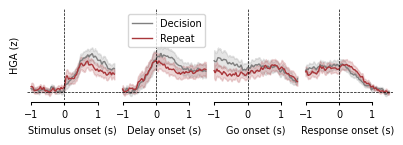

In [15]:
rois = ['AIC']

tasks = ['LexicalDelay']
colors = ['gray', red]
modality = ['sound']
description = ['Decision','Repeat']

subset = HGAs[
    (HGAs.task.isin(tasks))
    & (HGAs.roi.isin(rois))
    # & (HGAs.hemi == 'L')
    & (HGAs.description.isin(description))
    & (HGAs.modality.isin(modality))
    & (HGAs.subject.isin(picks))
    & (HGAs.subject!='D0121')
]


phases = ['stimulus', 'delay', 'go' ,'response']
fig, axes = plt.subplots(nrows=1, ncols=len(phases), figsize=(3*(len(phases))*cm, 3*cm))

plt.subplots_adjust(wspace=0)

# Create plots with proper labels for legend
for (phase, ax) in zip(phases, axes):
        
    legend_ = True if ax==axes[1] else False
    sns.lineplot(
        data=subset[(subset.phase == phase)],
        x='time',
        y='value',
        hue='description',
        hue_order=description,
        ax=ax,
        palette=colors,
        legend=legend_,
        lw=1
    )
    ax.set_xlabel(f'{phase.capitalize()} onset (s)', fontsize=7)   
    

for ax in fig.axes:
    ax.axvline(x=0, color='k', linestyle='--', linewidth=0.5)
    ax.axhline(y=0, color='k', linestyle='--', linewidth=0.5)
    
    ax.tick_params(labelsize=7, width=.75, length=2, which='both')
    plt.setp(ax.spines.values(), linewidth=.75)
    sns.despine(ax=ax, offset=1, trim=True)
    
    # Only add legend to the last axis if it has artists with labels
    if ax.get_legend() is not None:
        ax.legend(title='', fontsize=7)
    else:
        # Remove legend from other axes
        legend = ax.get_legend()
        if legend is not None:
            legend.remove()
    
    ax.set_yticklabels([])
    ax.set_yticks([])
    # remove y spine
    ax.spines['left'].set_visible(False)
    
    ax.set_ylim(-0.1, 1)
    
axes[0].set_ylabel('HGA (z)', fontsize=7)
for ax in axes[1:]:
    ax.set_ylabel('', fontsize=7)
    
plt.savefig(f'grantfig/aim1_modulation_{rois[0]}_lexical.svg', dpi=300, bbox_inches='tight')
plt.show()

In [16]:
# ── Load Decision vs Repeat univariate contrast results (BIDSPath style) ──
ref = 'bipolar'
contrast_paths = []
for t in ['LexicalNoDelay','LexicalDelay']:
    contrast_paths.extend(
        BIDSPath(
            root=f'../results/{t}({ref})',
            datatype='univariate',
            description='DecisionVsRepeat',
            suffix='highgamma',
            check=False,
        ).match()
    )

print(f"Found {len(contrast_paths)} contrast files")

contrast_dfs = []
for path in tqdm(contrast_paths):
    df = pd.read_csv(path)
    df['subject'] = path.subject
    df['task'] = path.task
    contrast_dfs.append(df)

dec_vs_rep = pd.concat(contrast_dfs, ignore_index=True)

# Merge ROI info from HGAs (channel + subject is unique key)
# Get unique channel metadata from HGAs
channel_meta = HGAs[['channel', 'roi', 'hemi', 'label', 'x', 'y', 'z']].drop_duplicates(subset='channel')
dec_vs_rep = dec_vs_rep.merge(channel_meta, on='channel', how='left')

# Exclude bad channels
dec_vs_rep = dec_vs_rep[~dec_vs_rep.channel.isin(exclude_chn)]

print(f"Total: {len(dec_vs_rep)} rows, {dec_vs_rep.subject.nunique()} subjects")
print(f"ROIs: {sorted(dec_vs_rep.roi.dropna().unique())}")

# take only the channel in HGAs
pick_chn = HGAs.channel.unique()
dec_vs_rep = dec_vs_rep[dec_vs_rep.channel.isin(pick_chn)]
dec_vs_rep.head()

Found 69 contrast files


100%|██████████| 69/69 [00:01<00:00, 37.22it/s]


Total: 2723520 rows, 49 subjects
ROIs: ['ACC', 'AG', 'AIC', 'Amyg', 'CGs', 'Calcarine', 'Cb', 'Central', 'CollatAnt', 'FuG', 'FuGs', 'GRect', 'Hipp', 'IFG', 'IFGs', 'IPL', 'ITG', 'InfLatV', 'Intersection', 'LatV', 'LinG', 'LinGs', 'MFG', 'MFGs', 'MTG', 'OFC', 'OFCs', 'OPC', 'OccS', 'PCC', 'PCun', 'PCuns', 'PIC', 'Paracentral', 'PhG', 'Put', 'SFG', 'SFGs', 'SMC', 'SMG', 'SPL', 'STG', 'STS', 'Sylvian', 'TP', 'Thal', 'VDC', 'dACC', 'iOccGs', 'mOccG']


,channel,time,mask,p,mean_a,mean_b,mean_diff,significant,direction,phase,subject,task,roi,hemi,label,x,y,z
0,D0024_LMST3-4,-1.000000,0,0.722256,0.114947,0.153243,-0.038296,True,Decision,response,D0024,LexicalNoDelay,ITG,L,ctx_lh_G_temporal_inf,-43.667929,-10.067674,-51.50411
1,D0024_LMST3-4,-0.992188,0,0.655069,0.086653,0.151536,-0.064883,True,Decision,response,D0024,LexicalNoDelay,ITG,L,ctx_lh_G_temporal_inf,-43.667929,-10.067674,-51.50411
2,D0024_LMST3-4,-0.984375,0,0.542292,0.053228,0.150837,-0.097609,True,Decision,response,D0024,LexicalNoDelay,ITG,L,ctx_lh_G_temporal_inf,-43.667929,-10.067674,-51.50411
3,D0024_LMST3-4,-0.976562,0,0.493901,0.034315,0.140174,-0.105859,True,Decision,response,D0024,LexicalNoDelay,ITG,L,ctx_lh_G_temporal_inf,-43.667929,-10.067674,-51.50411
4,D0024_LMST3-4,-0.968750,0,0.560688,0.033460,0.106091,-0.072632,True,Decision,response,D0024,LexicalNoDelay,ITG,L,ctx_lh_G_temporal_inf,-43.667929,-10.067674,-51.50411


In [17]:
phase = 'delay'
significant_delta = dec_vs_rep[
    (dec_vs_rep.significant == True) &
    (dec_vs_rep['mask'] == True) &
    (dec_vs_rep.phase == phase) &
    (dec_vs_rep.time>0) &   
    (dec_vs_rep.time<0.8)
]
significant_delta = significant_delta.groupby('channel').agg({
    'mean_diff': 'mean',  
    'x': 'first',
    'y': 'first', 
    'z': 'first',
    'roi': 'first',
    'label': 'first',
    'phase': 'first',
    'hemi': 'first',
    'subject': 'first',
    'direction':'first'
}).reset_index()

# rename mean_diff to delta
significant_delta.head()

,channel,mean_diff,x,y,z,roi,label,phase,hemi,subject,direction
0,D0024_LOF1-2,0.684720,-7.698818,47.243922,-46.443734,OFC,ctx_lh_G_orbital,delay,L,D0024,Decision
1,D0024_LTG10-11,-0.264256,-56.775694,30.278831,-32.773350,STG,ctx_lh_G_temp_sup-Plan_polar,delay,L,D0024,Repeat
2,D0027_LAI8-9,0.314923,-20.710699,50.213656,27.605527,SFGs,ctx_lh_S_front_sup,delay,L,D0027,Decision
3,D0027_LAI9-10,0.373357,-18.795727,54.350522,34.572697,SFG,ctx_lh_G_front_sup,delay,L,D0027,Decision
4,D0027_LMSF3-4,0.460927,-8.015543,28.461904,28.552207,dACC,ctx_lh_G_and_S_cingul-Mid-Ant,delay,L,D0027,Decision


Reading labels from parcellation...
   read 75 labels from /cwork/ns458/ECoG_Recon/cvs_avg35_inMNI152/label/lh.aparc.a2009s.annot
   read 75 labels from /cwork/ns458/ECoG_Recon/cvs_avg35_inMNI152/label/rh.aparc.a2009s.annot


2026-05-12 10:27:13.661 (1271.593s) [    7F6BA1429740]vtkXOpenGLRenderWindow.:1416  WARN| bad X server connection. DISPLAY=


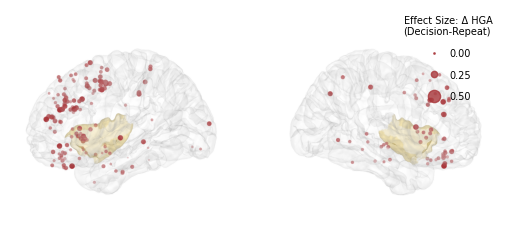

In [18]:
import numpy as np
import pyvista as pv
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from mne.viz import Brain
from scipy.spatial import cKDTree

labels = mne.read_labels_from_annot(
    subject='cvs_avg35_inMNI152', parc='aparc.a2009s',
    surf_name='pial',
    hemi='both', subjects_dir=recon_dir
)

lh_brain = Brain(
    "cvs_avg35_inMNI152", subjects_dir=recon_dir, surf="pial",
    hemi="lh", background="white", show=False,
    cortex=(0.9, 0.9, 0.9), alpha=0.1, size=(600*cm, 600*cm)
)
rh_brain = Brain(
    "cvs_avg35_inMNI152", subjects_dir=recon_dir, surf="pial",
    hemi="rh", background="white", show=False,
    cortex=(0.9, 0.9, 0.9), alpha=0.1, size=(600*cm, 600*cm)
)

# 使用显著数据进行可视化
cord = significant_delta[(significant_delta.direction=='Decision')][['x', 'y', 'z']].values
mean_delta = significant_delta[(significant_delta.direction=='Decision')]['mean_diff'].values

mask_lh = cord[:, 0] < 0
mask_rh = cord[:, 0] > 0

# Color + size mapping
cmap = reds
max_abs = np.percentile(np.abs(mean_delta), 95)
max_abs = max(max_abs, 1e-6)
norm = mcolors.TwoSlopeNorm(vmin=-max_abs, vcenter=0.0, vmax=max_abs)

size_min, size_max = 1, 35
alpha_min, alpha_max = 0.2, 1

def val_to_size(v, vmax_abs, size_min, size_max):
    x = np.clip(np.abs(v) / vmax_abs, 0, 1)
    return size_min + x * (size_max - size_min)

def val_to_alpha(v, vmax_abs, alpha_min, alpha_max):
    x = np.clip(np.abs(v) / vmax_abs, 0, 1)
    return alpha_min + x * (alpha_max - alpha_min)

def build_valid_vertex_mask(labels, hemi, n_vertices):
    m = np.zeros(n_vertices, dtype=bool)
    for lab in labels:
        if lab.hemi == hemi:
            m[lab.vertices] = True
    return m

def add_projected_points(brain, hemi, coords, vals, tree, surf_coords, valid_vertex_mask):
    if coords.size == 0:
        return

    _, indices = tree.query(coords)
    projected = surf_coords[indices]
    keep = valid_vertex_mask[indices]

    if not keep.any():
        return

    for pt, v in zip(projected[keep], vals[keep]):
        cloud = pv.PolyData(pt.reshape(1, 3))
        color = cmap(norm(v))[:3]
        size = val_to_size(v, max_abs, size_min, size_max)
        alpha = val_to_alpha(v, max_abs, alpha_min, alpha_max)
        brain._renderer.plotter.add_mesh(
            cloud,
            render_points_as_spheres=True,
            point_size=float(size),
            color=color,
            lighting=False,
            smooth_shading=False,
            opacity=float(alpha),
        )

lh_pial_path = f"{recon_dir}/cvs_avg35_inMNI152/surf/lh.pial"
lh_coords_pial, _ = mne.read_surface(lh_pial_path)
lh_tree = cKDTree(lh_coords_pial)
lh_valid_vertex = build_valid_vertex_mask(labels, 'lh', len(lh_coords_pial))

rh_pial_path = f"{recon_dir}/cvs_avg35_inMNI152/surf/rh.pial"
rh_coords_pial, _ = mne.read_surface(rh_pial_path)
rh_tree = cKDTree(rh_coords_pial)
rh_valid_vertex = build_valid_vertex_mask(labels, 'rh', len(rh_coords_pial))

if mask_lh.any():
    add_projected_points(
        lh_brain,
        'lh',
        cord[mask_lh],
        mean_delta[mask_lh],
        lh_tree,
        lh_coords_pial,
        lh_valid_vertex,
    )

if mask_rh.any():
    add_projected_points(
        rh_brain,
        'rh',
        cord[mask_rh],
        mean_delta[mask_rh],
        rh_tree,
        rh_coords_pial,
        rh_valid_vertex,
    )

insula_patterns = ['G_insular_short', 'G_Ins_lg_and_S_cent_ins',
                   'S_circular_insula_ant', 'S_circular_insula_inf', 'S_circular_insula_sup']
for lab in labels:
    if any(pattern in lab.name for pattern in insula_patterns):
        if lab.hemi == 'lh':
            lh_brain.add_label(lab, borders=False, color=insula_color, alpha=0.5)
        elif lab.hemi == 'rh':
            rh_brain.add_label(lab, borders=False, color=insula_color, alpha=0.5)


for brain in (lh_brain, rh_brain):
    brain.show_view(view="lateral", distance=400)
    brain._renderer.plotter.window_size = [1400, 1400]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16*cm, 8*cm), gridspec_kw={'width_ratios': [1, 1]})
# plt.subplots_adjust(wspace=0.02)
ax1.imshow(lh_brain.screenshot(mode="rgb"))
ax1.axis("off")

ax2.imshow(rh_brain.screenshot(mode="rgb"))
ax2.axis("off")

example_values = [0, max_abs * 0.5, max_abs]
example_labels = ['0.00', f'{max_abs * 0.5:.2f}', f'{max_abs:.2f}']

legend_scale = 0.35

handles = []
for v, lab in zip(example_values, example_labels):
    # PyVista point_size 是像素；Matplotlib markersize 是 points
    ps_px = val_to_size(v, max_abs, size_min, size_max)
    ms_pt = ps_px * 72.0 / fig.dpi * legend_scale
    h = plt.Line2D(
        [0], [0],
        marker='o',
        linestyle='None',
        markerfacecolor=red,
        markeredgecolor=red,
        markersize=max(1.0, ms_pt),
        alpha=0.8,
        label=lab,
    )
    handles.append(h)

ax2.legend(
    handles=handles,
    title='Effect Size: Δ HGA\n(Decision-Repeat)',
    loc='upper right',
    frameon=False,
    borderaxespad=0.2,
    handletextpad=0.6,
    labelspacing=1.2,
    fontsize=7,
    title_fontsize=7,
)

lh_brain.close()
rh_brain.close()

fig.savefig(f'grantfig/aim1_spatial_condition_difference.svg', dpi=300, bbox_inches='tight')